In [2]:
from profiling_and_attack import mlp_eshard, information, cnn, cnn_ASCAD, mlp

from sklearn.preprocessing import StandardScaler
from utils import *
from tensorflow.keras import Model
from tensorflow.keras.utils import to_categorical
from sklearn.decomposition import PCA
import sys
from matplotlib import pyplot as plt

2024-12-29 12:15:43.142224: I tensorflow/core/util/port.cc:113] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2024-12-29 12:15:43.355544: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:9261] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2024-12-29 12:15:43.355575: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:607] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2024-12-29 12:15:43.391461: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1515] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2024-12-29 12:15:43.462734: I tensorflow/core/platform/cpu_feature_guar

In [3]:
import tensorflow as tf

def train_linear_probe(x_train, y_train, epochs=5):
    """
    Defines and trains a linear probe with a dense layer on top of extracted features.
    
    Args:
        x_train (np.array or tf.Tensor): Training features.
        y_train (np.array or tf.Tensor): Training labels.
        
    Returns:
        tf.keras.Model: Trained linear probe model.
    """
    # Define the linear probe model (a simple dense layer on the input features)
    num_classes = len(set(y_train))  # Infer number of classes from labels
    model = tf.keras.Sequential([
        tf.keras.layers.Input(shape=x_train.shape[1:]),  # Input shape based on feature size
        tf.keras.layers.Dense(num_classes, activation="softmax")
    ])

    # Compile the model
    model.compile(optimizer="adam",
                  loss="sparse_categorical_crossentropy",
                  metrics=["accuracy"])

    # Train the linear probe
    model.fit(x_train, y_train, epochs=epochs, batch_size=400)

    return model

In [4]:
dataset_id = 'ascad-variable'
resample_window=80
traces_dim = 2000
model = cnn_ASCAD(256,traces_dim)
n_prof= 200000

def hw(input):

    result = np.zeros_like(input)
    for i in range(8):
        result += (input >> i) & 0x1
    return result


lm = "ID"
target_byte = 2
path = "/mnt/d/Datasets"
dataset = load_dataset(dataset_id, path, target_byte, traces_dim, leakage_model=lm, n_prof=n_prof)
pi_og, pi_patch_new, pi_patch_og = [], [], []
dataset.x_profiling, dataset.x_attack = scale_dataset(dataset.x_profiling, dataset.x_attack, StandardScaler())


2024-12-29 12:15:46.238197: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:887] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
2024-12-29 12:15:46.370720: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:887] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
2024-12-29 12:15:46.370759: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:887] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
2024-12-29 12:15:46.372028: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:887] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
2024-12-29 12:15:46.372057: I external/local_xla/xla/stream_executor

Model: "cnn_search"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_layer (InputLayer)    [(None, 2000, 1)]         0         
                                                                 
 conv_1 (Conv1D)             (None, 134, 12)           492       
                                                                 
 bn_1 (BatchNormalization)   (None, 134, 12)           48        
                                                                 
 average_pooling1d (Average  (None, 67, 12)            0         
 Pooling1D)                                                      
                                                                 
 conv_2 (Conv1D)             (None, 5, 24)             11544     
                                                                 
 bn_2 (BatchNormalization)   (None, 5, 24)             96        
                                                        

/cuda/cuda_executor.cc:887] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
2024-12-29 12:15:46.509070: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:887] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
2024-12-29 12:15:46.509109: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:887] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
2024-12-29 12:15:46.509115: I tensorflow/core/common_runtime/gpu/gpu_device.cc:2022] Could not identify NUMA node of platform GPU id 0, defaulting to 0.  Your kernel may not have been built with NUMA support.
2024-12-29 12:15:46.509139: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:887] could not open file to read NUMA node: /sys/bus/pci/devices/0000

In [33]:
def reload_model(epoch= 10, layers=1):
    global layer, model, tmp, tmp_att
    layer = layers
    model.load_weights(f"model_checkpoints/cnn_ascadr_{epoch:02d}.weights.h5")
    outputs = [model.layers[layer].output for layer in range(0, len(model.layers))]
    new_model = Model(model.inputs, outputs)
    tmp =  new_model.predict(dataset.x_profiling)
    #print(tmp.shape)
    tmp_att = new_model.predict(dataset.x_attack).copy()
sbox_ins = (dataset.profiling_plaintexts[:, dataset.target_byte].astype(np.uint8) ^ dataset.profiling_keys[:, dataset.target_byte].astype(np.uint8))
probes_for_bit = []

layer_out = 4
def retrain_probes_per_bit():
    global probes_for_bit
    probes_for_bit = []
    for k in range(8):

        probe_for_sbox_input = train_linear_probe(tmp[layer_out],(dataset.profiling_labels.astype(np.uint8)>>k)&0x1, epochs=5)
        probes_for_bit.append(probe_for_sbox_input)

    for k in range(8):

        probe_for_sbox_input = train_linear_probe(tmp[layer_out],(sbox_ins>>k)&0x1, epochs=5)
        probes_for_bit.append(probe_for_sbox_input)

In [6]:
reload_model(99)
#retrain_probes_per_bit()

2024-12-29 12:15:57.286074: I external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:454] Loaded cuDNN version 8904
2024-12-29 12:15:57.355553: I external/local_tsl/tsl/platform/default/subprocess.cc:304] Start cannot spawn child process: No such file or directory
2024-12-29 12:15:57.541591: I external/local_tsl/tsl/platform/default/subprocess.cc:304] Start cannot spawn child process: No such file or directory


313/313 [==============================] - 1s 2ms/step


In [7]:
acc_per_probe = []
#from tf.keras.metrics import acc
layer_out=4
sbox_ins_att = (dataset.attack_plaintexts[:, dataset.target_byte].astype(np.uint8) ^ dataset.attack_keys[:, dataset.target_byte].astype(np.uint8))

for i in range(8):
    y_pred = probes_for_bit[i].predict(tmp_att[layer_out])
    y_true = (dataset.attack_labels.astype(np.uint8) >>(i))&0x1
    acc = np.sum(np.equal(y_true, np.argmax(y_pred, axis=1)))/y_true.shape[0]
    print(f"Bit: {i}, acc: {acc}")


for i in range(8):
    y_pred = probes_for_bit[i+8].predict(tmp_att[layer_out])
    y_true = (sbox_ins_att >>(i))&0x1
    acc = np.sum(np.equal(y_true, np.argmax(y_pred, axis=1)))/y_true.shape[0]
    print(f"Bit: {i}, acc: {acc}")


IndexError: list index out of range

In [11]:
for i in tmp:
    print(i.shape)

(200000, 2000, 1)
(200000, 134, 12)
(200000, 134, 12)
(200000, 67, 12)
(200000, 5, 24)
(200000, 5, 24)
(200000, 3, 24)
(200000, 1, 36)
(200000, 1, 36)
(200000, 1, 36)
(200000, 1, 48)
(200000, 1, 48)
(200000, 1, 48)
(200000, 48)
(200000, 20)
(200000, 20)
(200000, 256)


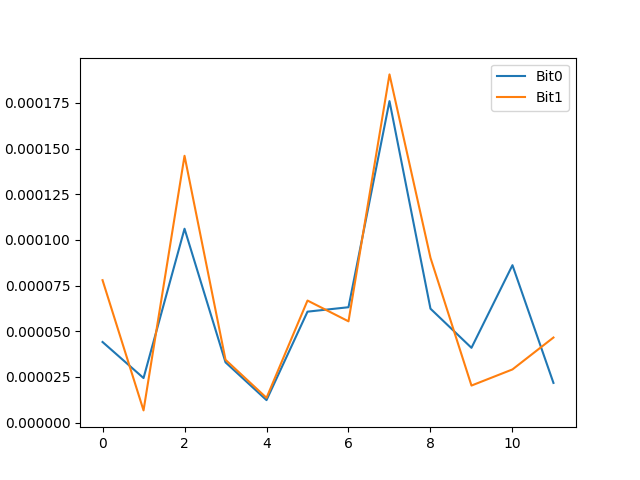

In [78]:
#reload_model(20)
layer = 14
layer_out = 15
new_model_for_probe = Model(model.layers[layer+1].input, model.layers[layer_out].output)
comp_n = 12

#retrain_probes_per_bit()
new_pca = PCA(n_components=comp_n)
new_s1_prof = new_pca.fit_transform(tmp[layer])
new_s1_att = new_pca.transform(tmp_att[layer])
in_neurons = tf.Variable(new_s1_att)

inf_scores = np.zeros((16, comp_n))
plt.clf()
for i in [0, 1]:
    with tf.GradientTape() as tape:
        inter = new_pca.inverse_transform(in_neurons)
        inter = new_model_for_probe(inter, training=False)
        
        predicts =  probes_for_bit[i+8](inter, training=True)#[:, 1] #+ probes_for_bit[i+1](inter, training=False)[:, 0]
        loss = tf.keras.losses.CategoricalCrossentropy()( predicts, tf.keras.utils.to_categorical((sbox_ins_att>>i)&0x1))
                
        # predicts =  probes_for_bit[i](inter, training=True)#[:, 1] #+ probes_for_bit[i+1](inter, training=False)[:, 0]
        # loss = tf.keras.losses.CategoricalCrossentropy()( predicts, tf.keras.utils.to_categorical((dataset.attack_labels>>i)&0x1))

    grads = tape.gradient(loss, in_neurons)
    dgrad_abs = tf.math.abs(grads)

    inf_score = np.average(dgrad_abs.numpy(), axis=0)
    inf_scores[i] = inf_score
    #print(inf_score)
    
    plt.plot(inf_score, label=f"Bit{i}")
# plt.plot(bit_on_sum)
# plt.plot(bit_off_sum)
plt.legend()
plt.show()

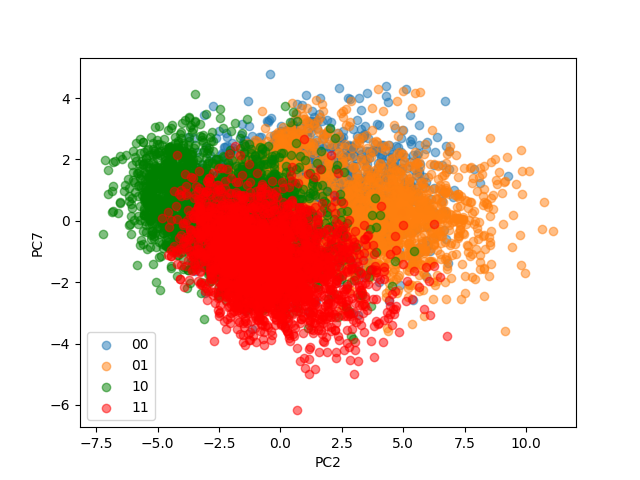

In [80]:
#reload_model(96)
from mpl_toolkits.mplot3d import Axes3D

comp_n= 12
new_pca = PCA(n_components=comp_n)
new_s1_prof = new_pca.fit_transform(tmp[layer])
new_s1_att = new_pca.transform(tmp_att[layer])
on = np.where(sbox_ins_att&0x3==0)
off = np.where(sbox_ins_att&0x3==1)
on2 = np.where(sbox_ins_att&0x3==2)
off3 = np.where(sbox_ins_att&0x3 ==3)
in1 = 4
in2 = 5
in1 = 2
in2 = 7
in3=6
fig = plt.figure()


# ax.scatter(new_s1_att[on, in1], new_s1_att[on, in2],new_s1_att[on, in3], label="00", alpha=0.1)
# ax.scatter(new_s1_att[off, in1], new_s1_att[off, in2],new_s1_att[off, in3],c='#ff7f0e', label="01", alpha=0.1)
# ax.scatter(new_s1_att[on2, in1], new_s1_att[on2, in2],new_s1_att[on2, in3], c='g',  label="10", alpha=0.3)
# ax.scatter(new_s1_att[off3, in1], new_s1_att[off3, in2], new_s1_att[off3, in3], c='r', label="11", alpha=0.3)
plt.xlabel(f"PC{in1}")
plt.ylabel(f"PC{in2}")

plt.scatter(new_s1_att[on, in1], new_s1_att[on, in2], label="00", alpha=0.5)
plt.scatter(new_s1_att[off, in1], new_s1_att[off, in2],c='#ff7f0e', label="01", alpha=0.5)
plt.scatter(new_s1_att[on2, in1], new_s1_att[on2, in2],c='g',  label="10", alpha=0.5)
plt.scatter(new_s1_att[off3, in1], new_s1_att[off3, in2], c='r', label="11", alpha=0.5)
plt.legend()

plt.show()
#plt.close()
# on = np.where(dataset.attack_labels&0x3==0)
# off = np.where(dataset.attack_labels&0x3==1)
# on2 = np.where(dataset.attack_labels&0x3==2)
# off3 = np.where(dataset.attack_labels&0x3 ==3)
# in1 = 2
# in2 = 3
# plt.xlabel(f"PC{in1}")
# plt.ylabel(f"PC{in2}")
# plt.scatter(new_s1_att[on, in1], new_s1_att[on, in2], label="00", alpha=0.5)
# plt.scatter(new_s1_att[off, in1], new_s1_att[off, in2],c='#ff7f0e', label="01", alpha=0.5)
# plt.scatter(new_s1_att[on2, in1], new_s1_att[on2, in2],c='g',  label="10", alpha=0.5)
# plt.scatter(new_s1_att[off3, in1], new_s1_att[off3, in2], c='r', label="11", alpha=0.5)
# plt.legend()
# plt.title("Bit 1 and 0 of $Sbox[p_i \oplus k_i]$")
# plt.show()
# plt.close()

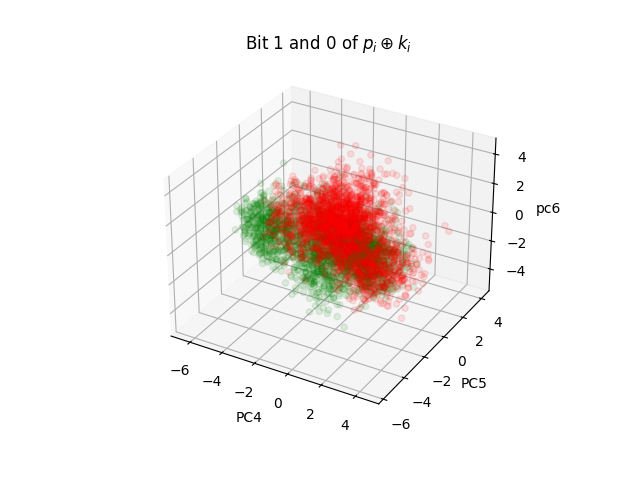

In [ ]:
%matplotlib widget 
from mpl_toolkits.mplot3d import Axes3D
layer = 13
layer_out = 15

comp_n= 12
new_pca = PCA(n_components=comp_n)
new_s1_prof = new_pca.fit_transform(tmp[layer])
new_s1_att = new_pca.transform(tmp_att[layer])
on = np.where(sbox_ins_att&0x3==0)
off = np.where(sbox_ins_att&0x3==1)
on2 = np.where(sbox_ins_att&0x3==2)
off3 = np.where(sbox_ins_att&0x3 ==3)
in1 = 4
in2 = 5
in1 = 4
in2 = 5
in3=6
fig = plt.figure()

ax = fig.add_subplot(projection='3d')
#ax = Axes3D(fig)

#ax.scatter(new_s1_att[on, in1], new_s1_att[on, in2],new_s1_att[on, in3], label="00", alpha=0.1)
#ax.scatter(new_s1_att[off, in1], new_s1_att[off, in2],new_s1_att[off, in3],c='#ff7f0e', label="01", alpha=0.1)
ax.scatter(new_s1_att[on2, in1], new_s1_att[on2, in2],new_s1_att[on2, in3], c='g',  label="10", alpha=0.1)
ax.scatter(new_s1_att[off3, in1], new_s1_att[off3, in2], new_s1_att[off3, in3], c='r', label="11", alpha=0.1)
ax.set_xlabel(f"PC{in1}")
ax.set_ylabel(f"PC{in2}")
ax.set_zlabel(f"pc{in3}")
# plt.scatter(new_s1_att[on, in1], new_s1_att[on, in2], label="00", alpha=0.5)
# plt.scatter(new_s1_att[off, in1], new_s1_att[off, in2],c='#ff7f0e', label="01", alpha=0.5)
# plt.scatter(new_s1_att[on2, in1], new_s1_att[on2, in2],c='g',  label="10", alpha=0.5)
# plt.scatter(new_s1_att[off3, in1], new_s1_att[off3, in2], c='r', label="11", alpha=0.5)
#ax.legend()
ax.set_title("Bit 1 and 0 of $p_i \oplus k_i$")

plt.show()
plt.close()

In [ ]:
 
on = np.where(dataset.attack_labels&0x3==0)
off = np.where(dataset.attack_labels&0x3==1)
on2 = np.where(dataset.attack_labels&0x3==2)
off3 = np.where(dataset.attack_labels&0x3 ==3)
in1 = 5
in2 = 1
plt.xlabel(f"PC{in1}")
plt.ylabel(f"PC{in2}")
plt.scatter(new_s1_att[on, in1], new_s1_att[on, in2], label="00", alpha=0.2)
plt.scatter(new_s1_att[off, in1], new_s1_att[off, in2],c='#ff7f0e', label="01", alpha=0.2)
plt.scatter(new_s1_att[on2, in1], new_s1_att[on2, in2],c='g',  label="10", alpha=0.5)
plt.scatter(new_s1_att[off3, in1], new_s1_att[off3, in2], c='r', label="11", alpha=0.5)
plt.legend()
plt.title("Bit 1 and 0 of $Sbox[p_i \oplus k_i]$")
plt.show()
plt.close()

ModuleNotFoundError: No module named 'ipympl'

In [ ]:
fix_in_01 = new_s1_att.copy()
fix_in_01[:, 1] = 16
fix_in_01[:, 2] = 12
fix_in_10 = new_s1_att.copy()
fix_in_10[:, 1] = 15
fix_in_10[:, 2] = -10
outs = []
new_model_for_probe = Model(model.layers[layer+1].input, model.layers[layer_out].output)
patched_activs = new_model_for_probe.predict(new_pca.inverse_transform(fix_in_01))
for i in range(8):
    outs.append(probes_for_bit[i].predict(patched_activs))
outs2 = []
patched_activs = new_model_for_probe.predict(new_pca.inverse_transform(fix_in_10))
for i in range(8):
    outs2.append(probes_for_bit[i].predict(patched_activs))



# for i in range(16):
#     print(f"in = {bin(i%4)}, out = {bin(i//4)}", matrix[i, :])       


313/313 [==============================] - 0s 878us/step


In [ ]:

matrix = np.zeros((16, 8))
matrix_in = np.zeros((16, 8))
for i in range(256):
    for bit in range(8):
        matrix[(i) %4 + (aes_sbox[i]%4)*4, bit] += (aes_sbox[i]>>bit) &0x1
        matrix_in[((i) %4)*4 + (aes_sbox[i]%4), bit] += (i>>bit) &0x1

print(matrix)
print(matrix_in)
out_bit = 0
indices_00, = np.where((dataset.attack_labels) % 2 == out_bit)
for pred_bit in range(2,8):
#pred_bit = 4

    print(1, pred_bit, matrix[1, pred_bit], np.sum((np.argmax(outs[pred_bit],axis=1))))
    print(2, pred_bit, matrix[0, pred_bit], np.sum((np.argmax(outs2[pred_bit],axis=1))))


[[ 0.  0.  9.  8. 11. 11. 10.  8.]
 [ 0.  0.  8.  9.  8.  6.  9.  6.]
 [ 0.  0.  8.  7.  8. 10.  6.  8.]
 [ 0.  0.  7.  8.  5.  5.  7. 10.]
 [15.  0.  5.  7.  3.  7. 10.  5.]
 [20.  0. 11. 10. 14.  6. 11. 14.]
 [11.  0.  6.  5.  5.  6.  2.  5.]
 [18.  0. 10. 10. 10. 13.  9.  8.]
 [ 0. 16.  6.  8.  8.  7. 11. 10.]
 [ 0. 16. 11.  7.  9.  9.  6.  6.]
 [ 0. 16.  7.  9.  9.  9.  8.  9.]
 [ 0. 16.  8.  8.  6.  7.  7.  7.]
 [12. 12.  5.  6.  6.  5.  7.  5.]
 [16. 16.  8.  6.  6.  9.  8. 11.]
 [20. 20. 11.  8. 10. 11.  8.  8.]
 [16. 16.  8. 12. 10.  7.  9.  8.]]
[[ 0.  0.  9. 11. 12. 11. 11. 11.]
 [ 0.  0.  7.  8.  6. 10.  8.  9.]
 [ 0.  0. 10.  9.  9.  4.  7.  7.]
 [ 0.  0.  6.  4.  5.  7.  6.  5.]
 [12.  0.  6.  6.  6.  5.  6.  5.]
 [20.  0. 10. 11.  9. 11. 12. 12.]
 [16.  0.  8.  7. 11.  9.  6. 11.]
 [16.  0.  8.  8.  6.  7.  8.  4.]
 [ 0. 17.  8.  8.  8.  9.  9. 11.]
 [ 0. 11.  5.  5.  7.  5.  6.  6.]
 [ 0. 16.  8.  9.  9.  9.  9.  7.]
 [ 0. 20. 11. 10.  8.  9.  8.  8.]
 [14. 14. 11.  5.  

804
26/26 [==============================] - 1s 21ms/step


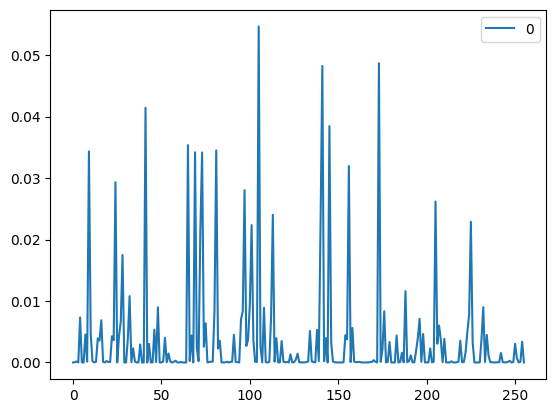

598
19/19 [==============================] - 0s 2ms/step


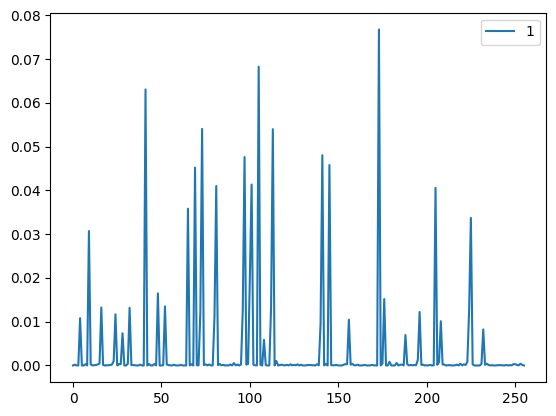

654
21/21 [==============================] - 0s 2ms/step


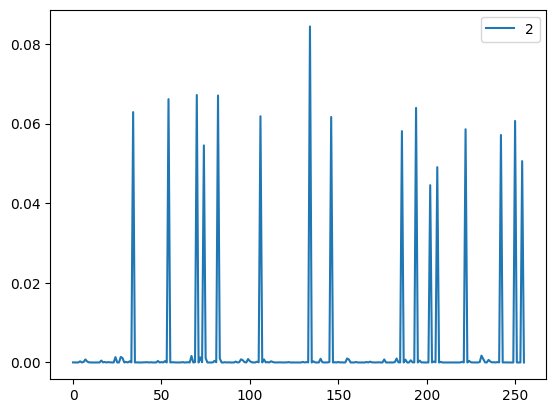

432
14/14 [==============================] - 0s 2ms/step


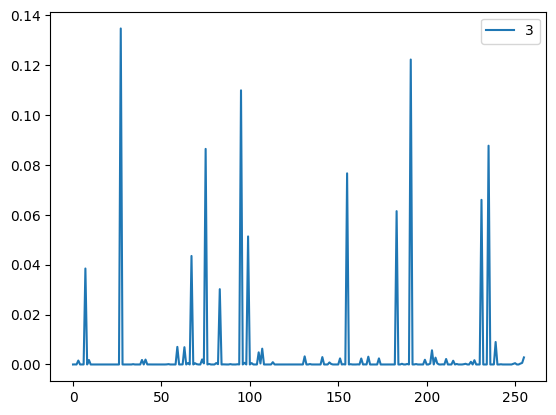

502
16/16 [==============================] - 0s 2ms/step


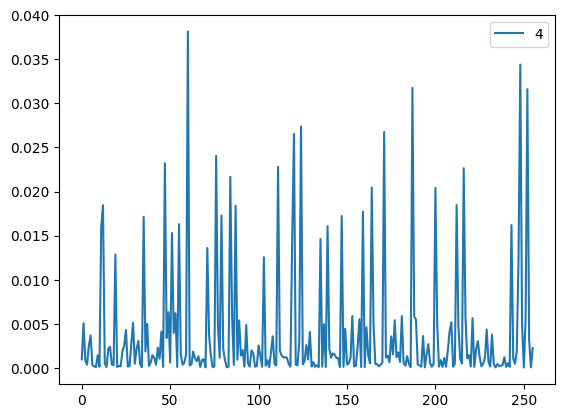

771
25/25 [==============================] - 0s 3ms/step


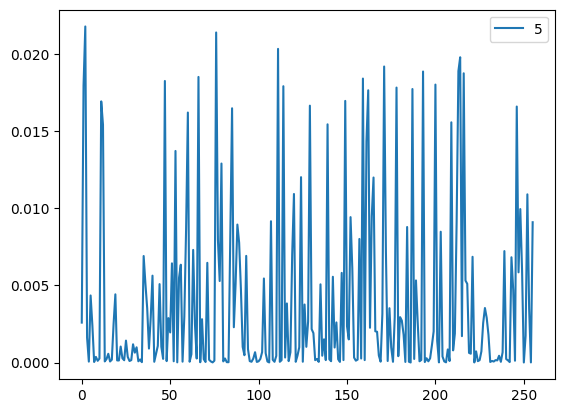

614
20/20 [==============================] - 0s 2ms/step


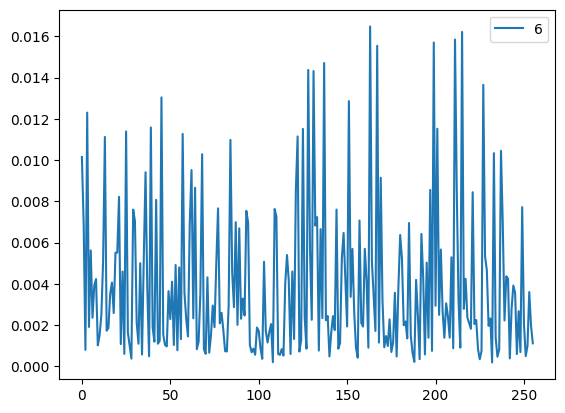

615
20/20 [==============================] - 0s 2ms/step


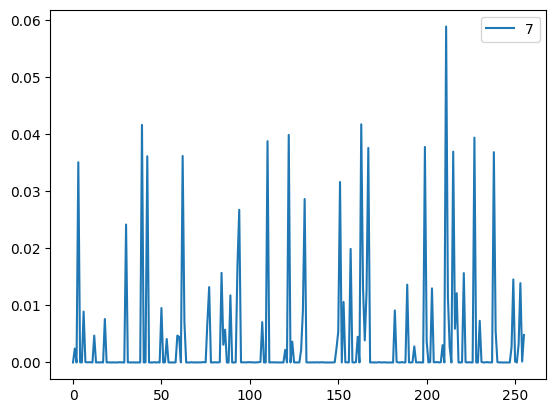

678
22/22 [==============================] - 0s 2ms/step


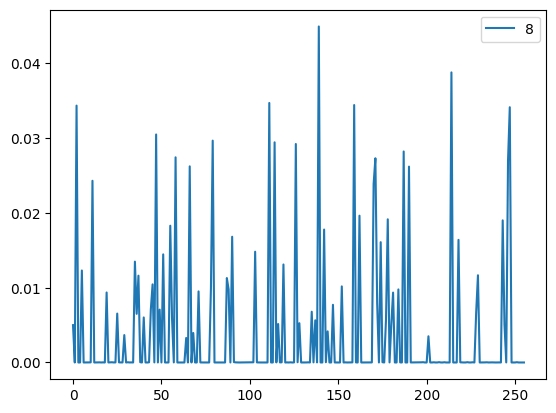

444
14/14 [==============================] - 0s 3ms/step


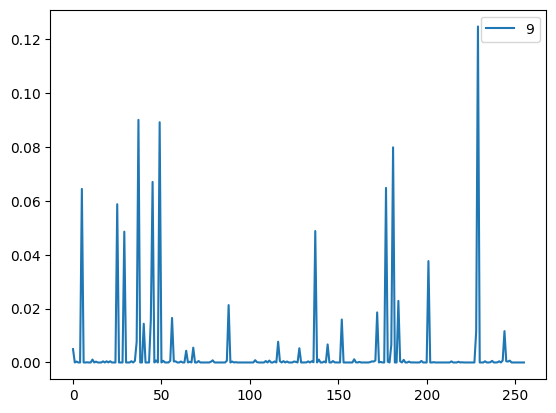

644
21/21 [==============================] - 0s 2ms/step


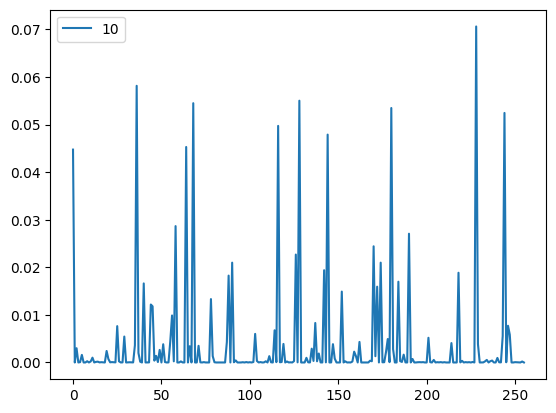

764
24/24 [==============================] - 0s 2ms/step


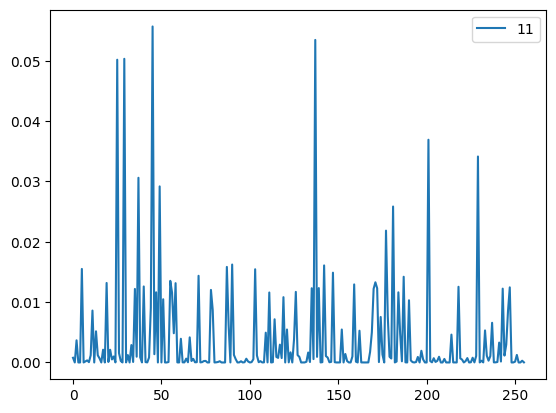

551
18/18 [==============================] - 0s 3ms/step


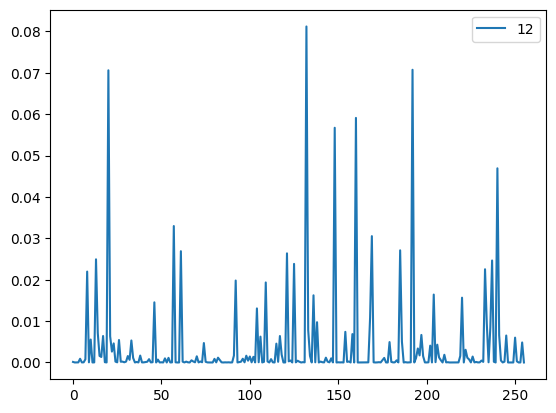

706
23/23 [==============================] - 0s 2ms/step


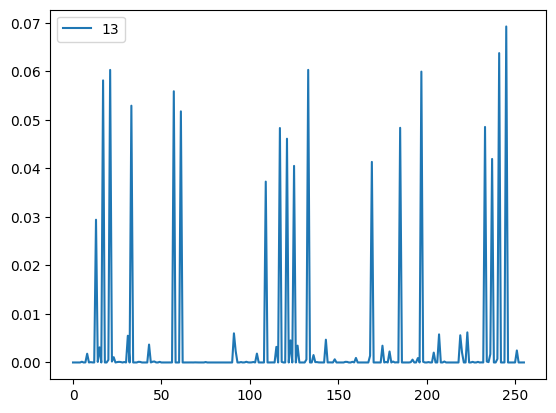

627
20/20 [==============================] - 0s 2ms/step


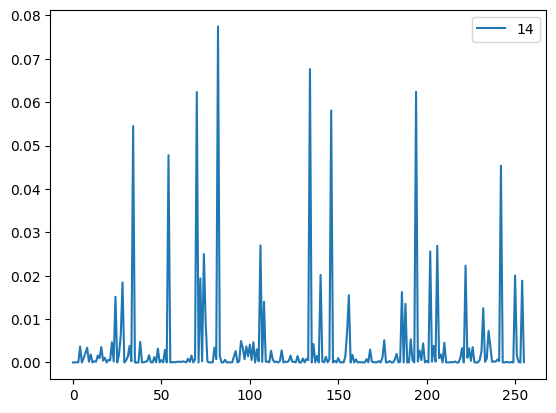

596
19/19 [==============================] - 0s 2ms/step


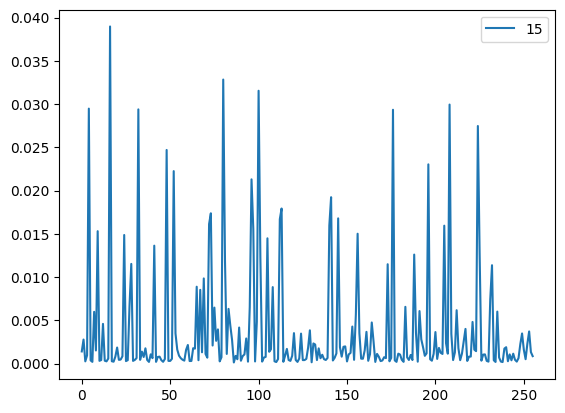

[array([1.87180819e-06, 4.68792277e-05, 1.68873885e-04, 5.61894194e-06,
       7.32484320e-03, 5.46140291e-06, 1.97903069e-06, 4.54733893e-03,
       1.35754904e-04, 3.43487412e-02, 4.67535201e-03, 1.97354806e-04,
       2.29570142e-05, 9.70656401e-05, 3.92905157e-03, 3.56431352e-03,
       6.87619438e-03, 1.04228129e-04, 2.47481717e-06, 2.44255469e-04,
       7.07079962e-05, 7.25468490e-05, 4.26472677e-03, 3.62089439e-03,
       2.93389596e-02, 2.18283162e-06, 4.31674067e-03, 6.65687351e-03,
       1.74896549e-02, 2.02112210e-06, 4.79033042e-06, 3.85942077e-03,
       1.07987039e-02, 6.48972855e-05, 2.29714834e-03, 1.51974193e-04,
       1.59001536e-06, 3.25066685e-06, 2.93471850e-03, 4.06947265e-06,
       1.64376081e-06, 4.14419509e-02, 1.70258215e-06, 3.01420223e-03,
       1.82498297e-06, 3.08995095e-06, 5.35550341e-03, 5.98532970e-05,
       8.98438506e-03, 8.92886192e-07, 1.42251861e-06, 1.50431151e-04,
       4.00657626e-03, 3.52773313e-05, 1.46560697e-03, 1.49071828e-04,
     

In [ ]:
out_logits = []
sbox_ins_att = (dataset.attack_plaintexts[:, dataset.target_byte].astype(np.uint8) ^ dataset.attack_keys[:, dataset.target_byte].astype(np.uint8))

for i in range(16):
    indices, =np.where((dataset.attack_labels %4 == i %4))
    indices_other, = np.where(sbox_ins_att  % 4 == (i >>2) %4)
    final_indices = np.intersect1d(indices, indices_other)
    print(len(final_indices))
    logits = model.predict(dataset.x_attack[final_indices])
    out_logits.append(logits[12])
    plt.plot(out_logits[i], label=i)

    plt.legend()
    plt.show()
print(out_logits)


In [ ]:
for i in range(16):
    indices, =np.where((dataset.attack_labels  == i))
    logits = model.predict(dataset.x_attack[indices])
    out_logits.append(np.median(logits, axis=0))
    plt.plot(out_logits[i], label=i)

    plt.legend()
    plt.show()
print(out_logits)

NameError: name 'np' is not defined

In [ ]:

for i in range(16):
     ins, = np.where(out_logits[i] > 0.01)
     print(i, ins)
     in_sboxes = []
     out_sboxes = []
     for j in range(256):
          if (j) % 4 == (i>>2):
               in_sboxes.append(aes_sbox[j])
          if j % 4 == i %4:
               out_sboxes.append(j)
     
     print(i, np.sort(np.intersect1d(in_sboxes, out_sboxes)))
#np.argsort(out_logits[1])[::-1]
#np.argsort(out_logits[2])[::-1]


0 [  9  24  28  32  41  65  69  72  73  81  97 101 105 113 140 141 145 156
 173 188 205 225]
0 [  4  16  24  28  32  48  52  72  80  96 100 108 112 140 156 176 188 196
 208 224 232]
1 [  4   9  16  24  32  41  48  52  65  69  72  73  80  81  96  97 100 101
 105 112 113 141 145 156 173 176 196 205 208 224 225]
1 [  9  41  65  69  73  81  97 101 105 113 141 145 173 205 225]
2 [ 34  54  70  74  82 106 134 146 186 194 202 206 222 242 250 254]
2 [ 34  54  70  74  82 106 134 146 186 194 202 206 222 242 250 254]
3 [  7  27  67  75  83  95  99 155 183 191 231 235]
3 [  7  27  67  75  83  95  99 155 183 191 231 235]
4 [ 11  12  19  35  47  51  55  60  71  76  79  84  87 103 111 119 120 124
 135 139 147 159 164 171 187 200 212 216 243 247 248 252]
4 [ 12  60  76  84 120 124 164 200 212 216 248 252]
5 [  1   2  11  12  47  53  60  66  76  79  85 111 114 120 124 129 139 149
 159 161 162 165 171 178 187 193 200 209 213 214 216 246 252]
5 [  1  53  77  85  89  93 129 149 153 157 161 165 189 193 209 